`Support Vector Classifier (SVC) `is a **supervised machine learning algorithm** that can be used for classification tasks. It works by finding the **optimal hyperplane** that separates data points of different classes in a **high-dimensional space**. SVC is particularly effective in cases where the classes are not linearly separable, as it can use **kernel functions** to transform the data into a higher-dimensional space where a linear separation is possible.

In [85]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [86]:
## let create synthetic data points
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=10000,n_classes=2,n_features=2,n_clusters_per_class=2,n_redundant=0)

In [87]:
pd.DataFrame(X)[0]

0       1.219043
1      -1.211686
2      -1.544216
3       1.229121
4       1.462242
          ...   
9995   -1.422969
9996   -0.735397
9997    0.559048
9998   -1.051850
9999    0.720297
Name: 0, Length: 10000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

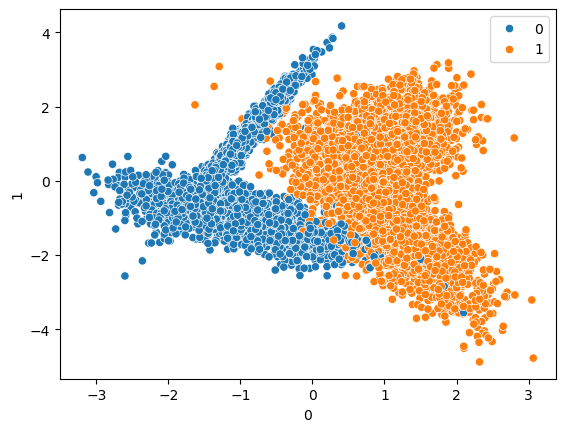

In [88]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [89]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [90]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
poly=SVC(kernel='poly')
rbf=SVC(kernel='rbf')
sig=SVC(kernel='sigmoid')


In [91]:
svc.fit(X_train,y_train)
poly.fit(X_train,y_train)
rbf.fit(X_train,y_train)
sig.fit(X_train,y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [92]:
y_pred=svc.predict(X_test)
y_pred_poly=poly.predict(X_test)
y_pred_rbf=rbf.predict(X_test)
y_pred_sig=sig.predict(X_test)

In [93]:
from sklearn.metrics import classification_report,confusion_matrix
print("Linear")
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("Polynomial")
print(classification_report(y_test,y_pred_poly))
print(confusion_matrix(y_test,y_pred_poly))
print("Gaussian")
print(classification_report(y_test,y_pred_rbf))
print(confusion_matrix(y_test,y_pred_rbf))
print("Sigmoid")
print(classification_report(y_test,y_pred_sig))
print(confusion_matrix(y_test,y_pred_sig))

Linear
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1275
           1       0.96      0.97      0.96      1225

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500

[[1223   52]
 [  40 1185]]
Polynomial
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1275
           1       0.94      0.99      0.96      1225

    accuracy                           0.96      2500
   macro avg       0.97      0.96      0.96      2500
weighted avg       0.97      0.96      0.96      2500

[[1192   83]
 [   7 1218]]
Gaussian
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1275
           1       0.98      0.98      0.98      1225

    accuracy                           0.98      2500
   macro avg       0.98      0.98      0.98    

Hyperparameter tuning is the process of choosing the best settings (hyperparameters) for a model before training so it performs better.

For SVC (Support Vector Classifier), important hyperparameters are:

- **C**: Controls balance between correct training fit and simplicity. Low C → simpler model, high C → fits training data more closely.
- **Kernel**: Type of transformation (linear, polynomial, RBF, sigmoid) that helps separate data.
- **Gamma (RBF only)**: How far a single data point influences the model. Low → wide influence, high → narrow influence.
- **Degree (poly kernel)**: Complexity of polynomial curve. Higher degree → more complex boundaries.
- **Class weight**: Gives more importance to minority classes (useful for imbalanced data).
- **Max iterations**: Limit on training steps; prevents infinite/long training.
- **Random state**: Ensures same results every run (reproducibility).
- **Shrinking**: Speeds up training by ignoring less useful data points.
- **Probability**: Enables probability outputs instead of just class labels (slower but useful).
- **Verbose**: Shows training details (mainly for debugging).
- **Cache size**: Memory used to speed up kernel computations.
- **Decision function shape**: Multi-class strategy — one-vs-one or one-vs-rest.
- **Break ties**: How to decide when classes are equally likely.

In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1,1,10,100,1000],'gamma':[1,0.1,0.01,0.001,0.0001],'kernel':['rbf']}

In [96]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,verbose=3)

In [97]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.979 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.983 total time=   0.1s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.986 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.979 total time=   0.1s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.978 total time=   0.1s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.979 total time=   0.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.979 total time=   0.1s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.983 total time=   0.2s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.979 total time=   0.2s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.976 total time=   0.2s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.967 total time=   0.5s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [98]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [100]:
y_pred_rbf=grid.predict(X_test)
print("Gaussian")
print(classification_report(y_test,y_pred_rbf))
print(confusion_matrix(y_test,y_pred_rbf))

Gaussian
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1275
           1       0.98      0.99      0.99      1225

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500

[[1256   19]
 [  15 1210]]


In [103]:
sig.intercept_

array([-2.05768418])

In [104]:
svc.coef_,svc.intercept_

(array([[3.10634877, 0.30017544]]), array([-0.07617124]))